# Generating and Validating the Synthetic Data

**Purpose.** This notebook builds a fully synthetic dataset for the international day-pass pricing case study, then validates it before anything downstream is fitted to it. No AT&T data is used, read, or reproduced anywhere in this project. Every value here is generated from parameters chosen by hand to be plausible.

It lives in `data/` rather than alongside the modelling notebooks (`01_state_model.ipynb` onward) deliberately — it's the one notebook in the series that produces data rather than consumes it, and keeping it next to the `synthetic/` and `powerbi/` folders it writes to makes that relationship visible in the file layout.

**Why synthesize rather than mock.** A random table would let the modeling code *run*; it would not let it be *checked*. This notebook generates data from an explicit behavioral process, so the true price sensitivity of every account is known. When the multiclass model is fit later, its estimates can be compared against the values that produced the data — which is a stronger test than anything real data offers.

**Two parts.**

| Part | Answers |
|---|---|
| 1 · Generation | What would the data look like? |
| 2 · Validation | Is it usable, and where is the label boundary? |

**What Part 1 produces**

| Table | Grain | Used for |
|---|---|---|
| `accounts` | one row per account | features, segmentation |
| `macro` | one row per month | simulation scenarios |
| `trips` | one row per account-trip | the modeling unit |
| `outcomes` | one row per account-trip | labels and revenue |
| `ground_truth` | one row per account | validation only — never a model input |

**Where randomness enters.** Deliberately at four levels, because a dataset with noise in only one place produces models that look far better than they are:

1. **Account heterogeneity** — each account draws its own latent price sensitivity and travel propensity.
2. **Macro path** — an AR(1) economic index shared by everyone, so trip volumes are *correlated across accounts*. This is the structure the plan flags as easy to get wrong in simulation.
3. **Trip-level draws** — trip counts, party size, and duration are all random given the account.
4. **Choice noise** — the behavioral state is drawn from a probability vector, not assigned deterministically.

**What Part 2 answers**, once the panel above exists:

1. **Does the panel look real?** Marginals, ratios and revenue concentration in ranges a telecom analyst would recognize.
2. **Is the label boundary readable from the data?** If `days_bought / days_traveled` is bimodal, the reduce/unchanged threshold reads off the shape instead of being picked arbitrarily.
3. **Is there enough price variation to estimate a response — per segment, not just overall?** A segment that never faced a price change cannot have its sensitivity estimated, and that has to be known before fitting, not after.

A failure in generation checks means fixing parameters in Part 1, above. A failure in the price-variation check means changing the price-variation design there too — neither is recoverable downstream.

## Plan

Part 1 runs in seven steps, each depending only on the ones above it.

1. **Accounts** — structure (lines, tenure, plan, business flag) and two latent traits: travel propensity and price sensitivity.
2. **Macro path** — 24 months of an AR(1) economic index; converted to a travel-volume multiplier applied to everyone at once.
3. **Trips** — Poisson draws per account-month, scaled by propensity × seasonality × macro. Each trip gets a destination, a party size, and a duration.
4. **Price faced** — the historical price variation the model will eventually learn from. Without variation there is nothing to estimate, so this is generated explicitly rather than assumed.
5. **Behavioral state** — a multinomial logit over the five states, driven by the account's latent sensitivity and the price it faced.
6. **Magnitude** — for the two states that need sizing (reduce, increase), how many lines and days were actually bought.
7. **Revenue** — the pricing identity applied to the realized lines and days.

Sanity checks and the ground-truth export follow as steps 8–9, then Part 2 picks up directly from what's in memory.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RNG = np.random.default_rng(20260820)

# This notebook lives in research_notebooks/data/, one level below the other
# notebooks, so its own data folder is a direct sibling rather than data/synthetic.
DATA = Path("synthetic")
DATA.mkdir(parents=True, exist_ok=True)

N_ACCOUNTS = 50_000
N_MONTHS = 24

# Product pricing
PRICE_FIRST_LINE = 10.0
PRICE_ADDL_LINE = 5.0

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# --- Chart style ------------------------------------------------------------
# A small fixed token set, not eyeballed: a validated categorical palette in
# fixed slot order (blue, orange, ... — see the dataviz skill's palette
# reference) for identity, one hue (blue) as the default magnitude/single-
# series color, and neutral ink/grid tokens for chrome. Used by every chart
# in both Part 1 and Part 2.
SURFACE = "#fcfcfb"   # chart background
INK = "#0b0b0b"       # primary text/ink
MUTED = "#898781"     # secondary ink, de-emphasis, neutral midpoint
GRID = "#e1e0d9"      # hairline gridlines
BASELINE = "#c3c2b7"  # axis line / reference line
ACCENT = "#2a78d6"    # categorical slot 1 (blue) — default single-series hue
ACCENT2 = "#eb6834"   # categorical slot 2 (orange) — second identity series
RED = "#e34948"       # diverging pole — revenue-negative states

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "grid.linestyle": "-",
    "axes.axisbelow": True,
    "font.size": 9,
    "text.color": INK,
    "axes.labelcolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
})

## 1 · Accounts

Two latent traits matter and neither is directly observable in real data:

- **`travel_propensity`** — expected international trips per month, lognormal so a minority of accounts travel far more than the median.
- **`price_sensitivity`** — how strongly this account reacts to a price change. Negative; nearer zero means less sensitive.

Sensitivity is generated as a function of observable characteristics *plus* an unexplained residual. That residual is the point: it means the eventual model cannot recover sensitivity perfectly, which is exactly the situation in production. A simulation where features fully determine the outcome teaches nothing about how the model will behave later.

In [2]:
def make_accounts(n, rng):
    is_business = rng.random(n) < 0.22

    # Business accounts skew to more lines
    lines = np.where(
        is_business,
        rng.choice([1, 2, 3, 4, 5], size=n, p=[0.15, 0.20, 0.25, 0.22, 0.18]),
        rng.choice([1, 2, 3, 4, 5], size=n, p=[0.38, 0.31, 0.17, 0.09, 0.05]),
    )

    tenure_months = rng.integers(1, 145, size=n)
    plan_tier = rng.choice(["value", "standard", "premium"], size=n, p=[0.30, 0.45, 0.25])
    premium = (plan_tier == "premium").astype(float)

    # Travel propensity: trips per month, lognormal
    log_prop = (
        -3.60
        + 1.55 * is_business
        + 0.35 * premium
        + 0.004 * (tenure_months - 72) / 12
        + rng.normal(0, 0.95, size=n)
    )
    travel_propensity = np.exp(log_prop)

    # Latent price sensitivity: negative, nearer zero = less sensitive.
    # Reimbursed business travel and premium plans are less sensitive;
    # the residual keeps it from being a deterministic function of features.
    price_sensitivity = (
        -1.60
        + 0.95 * is_business
        + 0.30 * premium
        + 0.08 * np.log1p(travel_propensity * 12)
        + rng.normal(0, 0.40, size=n)
    )
    price_sensitivity = np.clip(price_sensitivity, -3.0, -0.05)

    return pd.DataFrame({
        "account_id": np.arange(n),
        "is_business": is_business,
        "lines_on_account": lines,
        "tenure_months": tenure_months,
        "plan_tier": plan_tier,
        "travel_propensity": travel_propensity,
        "price_sensitivity": price_sensitivity,
    })


accounts = make_accounts(N_ACCOUNTS, RNG)
accounts.head()

,account_id,is_business,lines_on_account,tenure_months,plan_tier,travel_propensity,price_sensitivity
0,0,False,2,72,premium,0.008166,-0.817886
1,1,True,5,76,premium,0.615436,-0.265488
2,2,False,2,117,value,0.027803,-1.333017
3,3,False,2,97,standard,0.022454,-1.928163
4,4,True,1,2,premium,0.144453,-0.819382


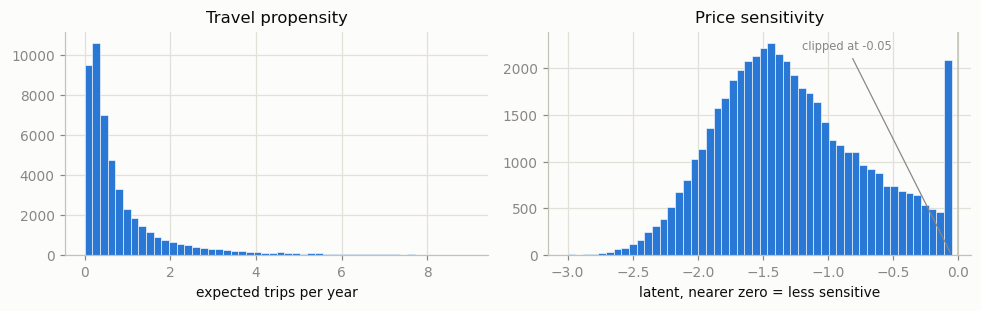

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 2.9))

prop_years = accounts["travel_propensity"] * 12
q99 = prop_years.quantile(0.99)
axes[0].hist(prop_years, bins=50, range=(0, q99), color=ACCENT,
             edgecolor=SURFACE, linewidth=0.4)
axes[0].set_title("Travel propensity")
axes[0].set_xlabel("expected trips per year")

axes[1].hist(accounts["price_sensitivity"], bins=50, color=ACCENT,
             edgecolor=SURFACE, linewidth=0.4)
axes[1].axvline(0, color=BASELINE, linewidth=1)
axes[1].set_title("Price sensitivity")
axes[1].set_xlabel("latent, nearer zero = less sensitive")
# The spike at -0.05 is real, not a plotting artifact: the generator clips
# price_sensitivity to [-3.0, -0.05], and enough business/premium accounts'
# raw draws land above that floor to pile up visibly at it.
axes[1].annotate("clipped at -0.05", xy=(-0.05, 0), xycoords=("data", "axes fraction"),
                  xytext=(0.60, 0.92), textcoords="axes fraction",
                  fontsize=7.5, color=MUTED, ha="left",
                  arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))

plt.tight_layout()
plt.show()

## 2 · Macro path

An AR(1) index standing in for economic expansion and contraction, converted to a multiplier on travel volume.

This is the piece that makes the later Monte Carlo honest. Every account's trip count in a given month is scaled by the *same* draw, so account outcomes are correlated. Simulating accounts independently would shrink the revenue distribution and report confidence the analysis has not earned.

In [4]:
def make_macro(n_months, rng, phi=0.85, sigma=0.35, gamma=0.55):
    """AR(1) economic index -> travel volume multiplier.

    phi   persistence; gamma how strongly the economy moves travel.
    """
    idx = np.zeros(n_months)
    for t in range(1, n_months):
        idx[t] = phi * idx[t - 1] + rng.normal(0, sigma)

    month = np.arange(n_months)
    # Northern-hemisphere leisure travel peaks mid-year and in December
    seasonality = (
        1.0
        + 0.15 * np.sin(2 * np.pi * (month % 12 - 2) / 12)
        + 0.06 * ((month % 12) == 11)
    )

    return pd.DataFrame({
        "month": month,
        "macro_index": idx,
        "seasonality": seasonality,
        "travel_multiplier": np.exp(gamma * idx) * seasonality,
    })


macro = make_macro(N_MONTHS, RNG)
macro.head()

,month,macro_index,seasonality,travel_multiplier
0,0,0.000000,0.870096,0.870096
1,1,-0.035610,0.925000,0.907060
2,2,-0.475274,1.000000,0.769973
3,3,-0.500878,1.075000,0.816146
4,4,-0.701075,1.129904,0.768389


/var/folders/rj/lg_9h2v52pnckdkdmwvvw3xr0000gn/T/ipykernel_47111/1216151477.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


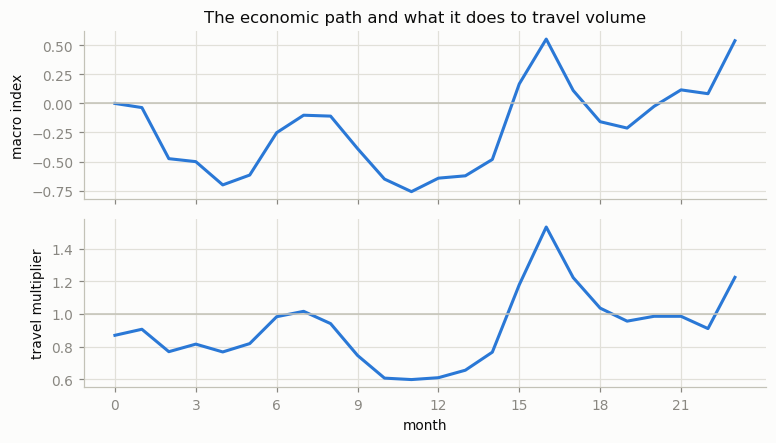

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 4.2), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1], "hspace": 0.12})

axes[0].plot(macro["month"], macro["macro_index"], color=ACCENT, linewidth=2)
axes[0].axhline(0, color=BASELINE, linewidth=1)
axes[0].set_ylabel("macro index")
axes[0].set_title("The economic path and what it does to travel volume")

axes[1].plot(macro["month"], macro["travel_multiplier"], color=ACCENT, linewidth=2)
axes[1].axhline(1.0, color=BASELINE, linewidth=1)
axes[1].set_ylabel("travel multiplier")
axes[1].set_xlabel("month")
axes[1].set_xticks(range(0, N_MONTHS, 3))

plt.tight_layout()
plt.show()

## 3 · Trips

Poisson trip counts per account-month. Each trip carries a destination region, how many of the account's lines travelled, and how many days.

Destination matters beyond geography: it proxies how easy the substitute is. A traveller in a market with mature eSIM coverage has a real alternative to the pass, which caps how far price can move regardless of what the elasticity says.

In [6]:
REGIONS = ["europe", "latam", "apac", "canada", "other"]
REGION_P = [0.34, 0.22, 0.18, 0.16, 0.10]
# Higher = easier to substitute the pass with eSIM / local SIM / Wi-Fi
SUBSTITUTE_EASE = {"europe": 0.85, "latam": 0.55, "apac": 0.70, "canada": 0.40, "other": 0.45}


def make_trips(accounts, macro, rng):
    prop = accounts["travel_propensity"].to_numpy()[:, None]      # (n, 1)
    mult = macro["travel_multiplier"].to_numpy()[None, :]         # (1, m)

    counts = rng.poisson(prop * mult)                             # (n, m)
    acct_idx, month_idx = np.nonzero(counts)
    reps = counts[acct_idx, month_idx]

    account_id = np.repeat(accounts["account_id"].to_numpy()[acct_idx], reps)
    month = np.repeat(month_idx, reps)
    n_trips = len(account_id)

    lines_available = accounts.set_index("account_id").loc[account_id, "lines_on_account"].to_numpy()
    is_business = accounts.set_index("account_id").loc[account_id, "is_business"].to_numpy()

    # Business trips are usually solo; leisure trips bring the household
    solo_p = np.where(is_business, 0.82, 0.32)
    solo = rng.random(n_trips) < solo_p
    lines_traveling = np.where(
        solo,
        1,
        1 + rng.binomial(np.maximum(lines_available - 1, 0), 0.75),
    )

    region = rng.choice(REGIONS, size=n_trips, p=REGION_P)

    # Duration: business trips shorter and tighter, leisure longer and more variable
    days = np.where(
        is_business,
        rng.lognormal(1.35, 0.40, size=n_trips),
        rng.lognormal(1.80, 0.60, size=n_trips),
    )
    days_traveled = np.clip(np.round(days), 1, 30).astype(int)

    return pd.DataFrame({
        "trip_id": np.arange(n_trips),
        "account_id": account_id,
        "month": month,
        "region": region,
        "lines_traveling": lines_traveling.astype(int),
        "days_traveled": days_traveled,
        "substitute_ease": [SUBSTITUTE_EASE[r] for r in region],
    })


trips = make_trips(accounts, macro, RNG)
print(f"{len(trips):,} trips across {trips.account_id.nunique():,} accounts")
trips.head()

94,440 trips across 29,312 accounts


,trip_id,account_id,month,region,lines_traveling,days_traveled,substitute_ease
0,0,1,0,canada,1,4,0.40
1,1,1,5,latam,1,5,0.55
2,2,1,5,latam,1,4,0.55
3,3,1,8,canada,5,4,0.40
4,4,1,8,europe,1,2,0.85


## 4 · Price faced

The most important step for realism, and the one most likely to be missing from real data.

A price response can only be estimated where the price actually moved. Here that variation is generated three ways: a market-level test that ran in some regions, a promotional window, and a small amount of account-level pricing drift. Roughly a third of trips end up facing something other than the standard rate.

The multiplier is deliberately **correlated with region and period, not random** — which reproduces the confounding problem the real analysis faces. Expensive markets and heavy travellers overlap, so a naive fit will attribute those differences to price. That is a feature of this dataset, not a flaw: it lets the modeling notebook demonstrate handling it.

In [7]:
def assign_price(trips, rng):
    n = len(trips)
    mult = np.ones(n)

    # (a) Market test: two regions carried a higher rate for months 8-15
    in_test = trips["region"].isin(["europe", "apac"]).to_numpy() & trips["month"].between(8, 15).to_numpy()
    mult = np.where(in_test, rng.choice([1.10, 1.20], size=n, p=[0.5, 0.5]), mult)

    # (b) Promotional window: a discount in the shoulder season
    in_promo = trips["month"].isin([4, 5, 16, 17]).to_numpy() & (rng.random(n) < 0.55)
    mult = np.where(in_promo & ~in_test, rng.choice([0.90, 0.95], size=n, p=[0.6, 0.4]), mult)

    # (c) Residual drift so the variation is not purely two clean blocks
    drift = (rng.random(n) < 0.10)
    mult = np.where(drift & ~in_test & ~in_promo, rng.choice([0.95, 1.10], size=n), mult)

    out = trips.copy()
    out["price_multiplier"] = mult
    out["price_first_line"] = PRICE_FIRST_LINE * mult
    out["price_addl_line"] = PRICE_ADDL_LINE * mult
    return out


trips = assign_price(trips, RNG)
print(trips["price_multiplier"].value_counts(normalize=True).sort_index().round(3))

price_multiplier
0.90    0.065
0.95    0.082
1.00    0.671
1.10    0.109
1.20    0.073
Name: proportion, dtype: float64


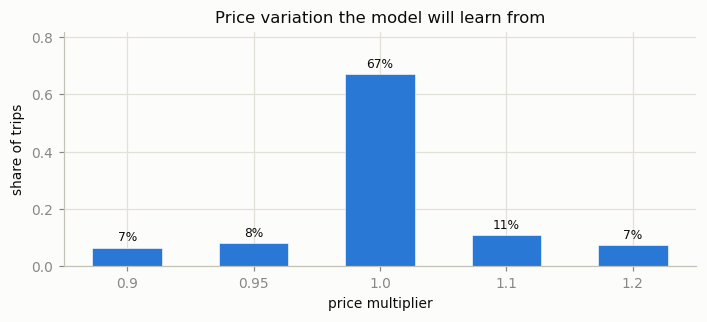

In [8]:
price_share = trips["price_multiplier"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(6.5, 3))
bars = ax.bar(price_share.index.astype(str), price_share.values, width=0.55,
              color=ACCENT, edgecolor=SURFACE, linewidth=0.4)
for b, v in zip(bars, price_share.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.0%}",
            ha="center", va="bottom", fontsize=8, color=INK)
ax.set_ylim(0, price_share.max() * 1.22)
ax.set_xlabel("price multiplier")
ax.set_ylabel("share of trips")
ax.set_title("Price variation the model will learn from")
plt.tight_layout()
plt.show()

## 5 · Behavioral state

A multinomial logit over the five states, with `unchanged` as the reference. Utilities move with `sensitivity × log(price multiplier)`, so a price rise pushes probability toward leaving, substituting and reducing, and a price cut pushes it toward increasing.

Three structural choices worth naming, because they are what make the dataset hard in the right ways:

- **Leaving is rare** (a large negative intercept) but expensive. This reproduces the class-imbalance problem the plan flags: an untreated model will barely predict it and the simulation will understate the downside.
- **Substitution scales with `substitute_ease`.** Where a good alternative exists, the price ceiling is lower — regardless of how price-insensitive the traveller is.
- **Increasing is only reachable on a discount.** Nobody buys more days because the price went up.

In [9]:
STATES = ["leaves", "substitutes", "reduces", "unchanged", "increases"]


def state_probabilities(trips, accounts):
    a = accounts.set_index("account_id").loc[trips["account_id"].to_numpy()]
    sens = a["price_sensitivity"].to_numpy()          # negative
    is_business = a["is_business"].to_numpy()
    tenure = a["tenure_months"].to_numpy()

    logp = np.log(trips["price_multiplier"].to_numpy())   # >0 increase, <0 discount
    ease = trips["substitute_ease"].to_numpy()
    party = trips["lines_traveling"].to_numpy()

    # Relief from the multi-line rate: a solo traveler pays the full first-line
    # rate per head; a party of `party` pays (first + addl*(party-1))/party per
    # head, which falls below the first-line rate as party grows. Expressed as
    # a 0-to-~0.4 "relief" score (0 = solo, no relief) so that larger, more
    # relieved parties get a MORE negative u_reduces term below — i.e. they are
    # structurally less exposed to a headline increase and less likely to cut
    # back. (Earlier version of this ratio ran the other way and had larger
    # parties reducing *more* than solo travelers — the opposite of the
    # intended relationship.)
    eff_price_relief = 1.0 - (PRICE_FIRST_LINE + PRICE_ADDL_LINE * (party - 1)) / (PRICE_FIRST_LINE * party)

    u_unchanged = np.zeros(len(trips))

    u_leaves = (
        -5.20
        + (-sens) * 1.10 * logp
        - 0.55 * is_business
        - 0.004 * tenure
    )

    u_substitutes = (
        -2.60
        + (-sens) * 1.85 * logp
        + 1.30 * ease
        - 0.70 * is_business
    )

    u_reduces = (
        -1.90
        + (-sens) * 1.55 * logp
        + 0.45 * ease
        - 0.40 * is_business
        - 0.80 * eff_price_relief
    )

    # Only reachable when logp < 0
    u_increases = (
        -2.40
        + (-sens) * 2.10 * (-np.minimum(logp, 0))
        - 3.00 * np.maximum(logp, 0)
    )

    U = np.column_stack([u_leaves, u_substitutes, u_reduces, u_unchanged, u_increases])
    U = U - U.max(axis=1, keepdims=True)
    P = np.exp(U)
    return P / P.sum(axis=1, keepdims=True)


P = state_probabilities(trips, accounts)
drawn = np.array([RNG.choice(5, p=row) for row in P]) if len(P) < 5_000 else (
    (P.cumsum(axis=1) < RNG.random((len(P), 1))).sum(axis=1)
)
trips["state"] = [STATES[i] for i in drawn]

print(trips["state"].value_counts(normalize=True).round(4))

state
unchanged      0.7281
reduces        0.1128
substitutes    0.0924
increases      0.0643
leaves         0.0024
Name: proportion, dtype: float64


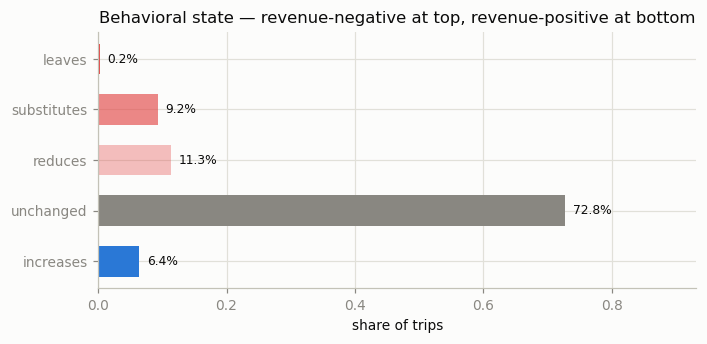

In [10]:
# Ordered loss -> neutral -> gain, colored to match: the three loss states
# share one hue (red) at decreasing opacity by severity, unchanged is neutral
# gray, increases is the single gain state in the accent blue. This is a
# diverging treatment (there's a real neutral baseline, "unchanged"), not a
# nominal categorical one.
STATE_ORDER = ["leaves", "substitutes", "reduces", "unchanged", "increases"]
STATE_STYLE = {
    "leaves":      dict(color=RED, alpha=1.00),
    "substitutes": dict(color=RED, alpha=0.65),
    "reduces":     dict(color=RED, alpha=0.35),
    "unchanged":   dict(color=MUTED, alpha=1.00),
    "increases":   dict(color=ACCENT, alpha=1.00),
}

state_share = trips["state"].value_counts(normalize=True).reindex(STATE_ORDER)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
y = np.arange(len(STATE_ORDER))
for yi, s in zip(y, STATE_ORDER):
    ax.barh(yi, state_share[s], height=0.6, **STATE_STYLE[s])
    ax.text(state_share[s] + 0.012, yi, f"{state_share[s]:.1%}",
            va="center", fontsize=8, color=INK)
ax.set_yticks(y)
ax.set_yticklabels(STATE_ORDER)
ax.invert_yaxis()
ax.set_xlim(0, state_share.max() * 1.28)
ax.set_xlabel("share of trips")
ax.set_title("Behavioral state — revenue-negative at top, revenue-positive at bottom")
plt.tight_layout()
plt.show()

## 6 · Magnitude

Three states are self-sizing. `unchanged` buys every travel day for every travelling line; `substitutes` and `leaves` buy nothing.

The other two need a size, and the size responds to price: a bigger increase produces a deeper cut, not just more cutters. Both the day count and the line count can move, since a household can put one phone on the pass and share it.

**Unchanged is not exactly full coverage.** A minority of unchanged trips buy one day less than they travelled for reasons that have nothing to do with price: a late arrival, a leg with hotel wifi, forgetting to activate on the last day. This incidental shortfall is generated deliberately. Without it, every unchanged trip sits exactly at 1.0, the reduce-versus-unchanged boundary is trivially separable, and the labelling notebook cannot test a decision that in production is genuinely hard.

In [11]:
def make_magnitudes(trips, accounts, rng):
    n = len(trips)
    state = trips["state"].to_numpy()
    days_t = trips["days_traveled"].to_numpy()
    lines_t = trips["lines_traveling"].to_numpy()
    logp = np.log(trips["price_multiplier"].to_numpy())
    # Physical cap on how many lines an account can activate — needed below so
    # "increases" trips can't add a line past what the account actually has.
    lines_cap = accounts.set_index("account_id").loc[trips["account_id"].to_numpy(), "lines_on_account"].to_numpy()

    days_bought = days_t.copy().astype(float)
    lines_active = lines_t.copy().astype(float)

    # --- reduces: keep the pass, buy less of it ---
    m = state == "reduces"
    # Deeper cuts at higher prices: Beta mean shifts down as logp rises
    mean_share = np.clip(0.55 - 1.20 * logp[m], 0.10, 0.85)
    conc = 6.0
    share = rng.beta(mean_share * conc, (1 - mean_share) * conc)
    days_bought[m] = np.maximum(np.round(days_t[m] * share), 1)
    # Some of the reduction comes out of lines instead of days
    drop_line = (rng.random(m.sum()) < 0.35) & (lines_t[m] > 1)
    la = lines_active[m]
    la[drop_line] = np.maximum(np.round(la[drop_line] * rng.uniform(0.4, 0.8, drop_line.sum())), 1)
    lines_active[m] = la

    # --- increases: buy more days, occasionally add a line ---
    m = state == "increases"
    # Floor at 1: an account that responded to a discount must be observably different
    # Floor at 1 extra day, but let the DEPTH of the discount matter: a low clip
    # floor would pin the mean across the whole tested range and make increase
    # size price-invariant by construction.
    extra = 1 + rng.poisson(np.clip(-12.0 * logp[m], 0.05, 4.0))
    days_bought[m] = days_t[m] + extra
    add_line = (rng.random(m.sum()) < 0.25)
    la = lines_active[m]
    cap = lines_cap[m]
    # Cap at the account's total lines — can't activate more pass lines than exist.
    la[add_line] = np.minimum(la[add_line] + 1, cap[add_line])
    lines_active[m] = la

    # --- unchanged: incidental shortfall, not a price response ---
    # Arrival late in the day, a leg with wifi, forgetting to activate. This is the
    # noise that makes reduce-vs-unchanged a real decision rather than a formality.
    m = state == "unchanged"
    incidental = (rng.random(m.sum()) < 0.12) & (days_t[m] >= 3)
    db = days_bought[m]
    # Mostly one day, occasionally two: a rule that keys on "two or more days short"
    # must be able to misfire, or its precision is an artefact of the generator.
    lost = np.where(rng.random(incidental.sum()) < 0.20, 2, 1)
    db[incidental] = np.maximum(db[incidental] - lost, 1)
    days_bought[m] = db

    # --- no purchase ---
    m = np.isin(state, ["substitutes", "leaves"])
    days_bought[m] = 0
    lines_active[m] = 0

    out = trips.copy()
    out["days_bought"] = days_bought.astype(int)
    out["lines_active"] = lines_active.astype(int)
    return out


trips = make_magnitudes(trips, accounts, RNG)
trips.groupby("state")[["days_traveled", "days_bought", "lines_traveling", "lines_active"]].mean().round(2)

,days_traveled,days_bought,lines_traveling,lines_active
state,,,,
increases,5.40,6.60,1.41,1.56
leaves,6.23,0.00,1.42,0.00
reduces,5.73,3.04,1.36,1.27
substitutes,5.88,0.00,1.46,0.00
unchanged,5.42,5.29,1.41,1.41


## 7 · Revenue

The pricing identity applied to what was actually bought:

```
revenue = (price_first_line + price_addl_line × (lines_active − 1)) × days_bought
```

`leaves` is recorded separately. Losing the account costs far more than the pass — it removes the whole relationship — so carrying it as a zero-revenue trip would understate the damage. The account-level loss is attached here and left for the revenue model to weight, rather than being buried inside a trip row.

In [12]:
def compute_revenue(trips):
    out = trips.copy()
    active = out["lines_active"].to_numpy()
    rev = np.where(
        active > 0,
        (out["price_first_line"].to_numpy() + out["price_addl_line"].to_numpy() * (active - 1))
        * out["days_bought"].to_numpy(),
        0.0,
    )
    out["pass_revenue"] = rev
    out["account_lost"] = (out["state"] == "leaves").astype(int)
    return out


trips = compute_revenue(trips)

print(f"Total pass revenue: ${trips.pass_revenue.sum():,.0f}")
print(f"Accounts lost:      {trips.account_lost.sum():,}")
trips.groupby("state")["pass_revenue"].agg(["count", "sum", "mean"]).round(2)

Total pass revenue: $5,407,880
Accounts lost:      224


,count,sum,mean
state,,,
increases,6072,519138.0,85.50
leaves,224,0.0,0.00
reduces,10654,376216.0,35.31
substitutes,8730,0.0,0.00
unchanged,68760,4512525.5,65.63


## 8 · Sanity checks

A synthetic dataset is only useful if it behaves the way the domain says it should. If any of these fail, the parameters are wrong and nothing downstream is worth fitting.

1. Revenue per trip moves coherently with price, and the raw and composition-adjusted views agree.
2. Business accounts are measurably less sensitive than consumer accounts.
3. Substitution is more common where the alternative is easier.
4. Trip volume tracks the macro index.

In [13]:
chk = trips.merge(accounts[["account_id", "is_business"]], on="account_id")

print("1 · Revenue per trip by price multiplier — raw, then within segment x region")
raw = chk.groupby("price_multiplier")["pass_revenue"].mean().round(2)
adj = (chk.groupby(["is_business", "region", "price_multiplier"])["pass_revenue"].mean()
       .groupby("price_multiplier").mean().round(2))
print(pd.DataFrame({"raw": raw, "within segment x region": adj}).to_string(), "\n")
print("Expectation: revenue per trip RISES with price if demand is net inelastic in")
print("this range, which is the finding the project is testing for. What must not")
print("happen is the raw and adjusted columns telling different stories — that would")
print("mean the pattern is composition, not response.\n")

print("2 · Share of trips buying nothing, by price and segment")
chk["no_purchase"] = chk["days_bought"].eq(0)
print(chk.pivot_table(index="price_multiplier", columns="is_business",
                      values="no_purchase", aggfunc="mean").round(3), "\n")

print("3 · Substitution rate by region")
print(chk.assign(sub=chk.state.eq("substitutes")).groupby("region")["sub"].mean().round(3), "\n")

print("4 · Correlation of monthly trip volume with macro index")
vol = trips.groupby("month").size().rename("trips").reset_index().merge(macro, on="month")
print(round(vol["trips"].corr(vol["macro_index"]), 3))

1 · Revenue per trip by price multiplier — raw, then within segment x region
                    raw  within segment x region
price_multiplier                                
0.90              55.27                    57.79
0.95              55.66                    58.15
1.00              57.18                    59.98
1.10              58.43                    62.03
1.20              59.87                    62.60 

Expectation: revenue per trip RISES with price if demand is net inelastic in
this range, which is the finding the project is testing for. What must not
happen is the raw and adjusted columns telling different stories — that would
mean the pattern is composition, not response.

2 · Share of trips buying nothing, by price and segment
is_business       False  True 
price_multiplier              
0.90              0.091  0.059
0.95              0.116  0.063
1.00              0.118  0.067
1.10              0.165  0.080
1.20              0.205  0.100 

3 · Substitution rate by 

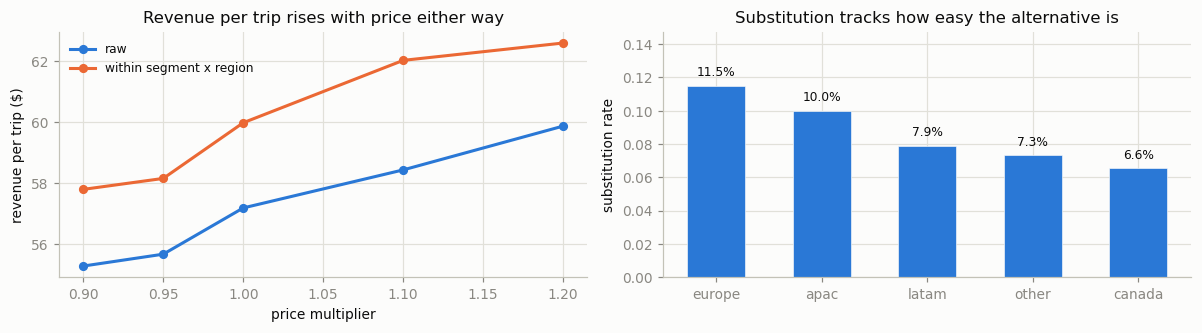

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.1))

comp = pd.DataFrame({"raw": raw, "within segment x region": adj})
axes[0].plot(comp.index, comp["raw"], color=ACCENT, linewidth=2, marker="o", ms=5, label="raw")
axes[0].plot(comp.index, comp["within segment x region"], color=ACCENT2, linewidth=2,
             marker="o", ms=5, label="within segment x region")
axes[0].set_xlabel("price multiplier")
axes[0].set_ylabel("revenue per trip ($)")
axes[0].set_title("Revenue per trip rises with price either way")
axes[0].legend(frameon=False, fontsize=8)

sub_by_region = (chk.assign(sub=chk.state.eq("substitutes"))
                  .groupby("region")["sub"].mean().sort_values(ascending=False))
bars = axes[1].bar(sub_by_region.index, sub_by_region.values, width=0.55,
                    color=ACCENT, edgecolor=SURFACE, linewidth=0.4)
for b, v in zip(bars, sub_by_region.values):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 0.004, f"{v:.1%}",
                 ha="center", va="bottom", fontsize=8, color=INK)
axes[1].set_ylim(0, sub_by_region.max() * 1.28)
axes[1].set_ylabel("substitution rate")
axes[1].set_title("Substitution tracks how easy the alternative is")

plt.tight_layout()
plt.show()

## 9 · Ground truth

Written to a separate file and **never joined into the modeling data**.

This is the advantage synthetic data has over the real thing: the modeling notebook can be scored on whether it recovers the sensitivity that actually generated the behavior, not just on how well it fits. If the model cannot recover a signal that is provably present, the problem is the model — not the data.

In [15]:
ground_truth = accounts[["account_id", "price_sensitivity", "travel_propensity"]].copy()
ground_truth["sensitivity_decile"] = pd.qcut(ground_truth["price_sensitivity"], 10, labels=False)

# Model-facing tables exclude the latent traits
model_accounts = accounts.drop(columns=["price_sensitivity", "travel_propensity"])

# Parquet is preferred (smaller, keeps dtypes) but needs pyarrow or fastparquet.
# Fall back to CSV so the notebook runs on a bare pandas install.
try:
    import pyarrow  # noqa: F401
    FMT = "parquet"
except ImportError:
    try:
        import fastparquet  # noqa: F401
        FMT = "parquet"
    except ImportError:
        FMT = "csv"
        print("pyarrow/fastparquet not found, writing CSV instead.")
        print("For smaller files:  pip install pyarrow\n")


def save(df, name):
    path = DATA / f"{name}.{FMT}"
    df.to_parquet(path, index=False) if FMT == "parquet" else df.to_csv(path, index=False)
    return path


for df, name in [(model_accounts, "accounts"), (macro, "macro"),
                 (trips, "trips"), (ground_truth, "ground_truth")]:
    save(df, name)

print(f"Written to {DATA.resolve()}")
for f in sorted(DATA.glob(f"*.{FMT}")):
    print(f"  {f.name:24s} {f.stat().st_size/1e6:6.2f} MB")

Written to /Users/paforsey/Inbox/Projects/data-science-portfolio/case-studies/international-roaming/research_notebooks/data/synthetic
  account_departure_risk.parquet   0.24 MB
  account_price_response.parquet   1.20 MB
  accounts.parquet           0.39 MB
  deterministic_revenue_curve.parquet   0.00 MB
  ground_truth.parquet       1.32 MB
  macro.parquet              0.00 MB
  magnitude_meta.parquet     0.00 MB
  model_meta.parquet         0.00 MB
  price_sweep.parquet        0.00 MB
  revenue_by_state.parquet   8.69 MB
  scored_trips.parquet       1.87 MB
  simulation_assumptions.parquet   0.00 MB
  simulation_price_sweep.parquet   0.01 MB
  simulation_scenarios.parquet   0.00 MB
  trip_magnitudes.parquet    1.88 MB
  trips.parquet              1.41 MB


---
# Part 2 · Validating the Synthetic Data

**Purpose.** Confirm the generated panel behaves like a plausible telecom travel population before anything is fitted to it, and settle the one decision the modeling depends on: how to reconstruct the five behavioral states from observable quantities.

This is not exploratory analysis in the usual sense. The generating process above is known, so nothing here is a discovery. Every check below either **validates the generator** or **produces a number the labeling rule needs**.

**Three questions**

1. **Does the panel look real?** Marginals, ratios and revenue concentration in ranges a telecom analyst would recognize.
2. **Is the label boundary readable from the data?** If `days_bought / days_traveled` is bimodal, the reduce/unchanged threshold reads off the shape instead of being picked arbitrarily.
3. **Is there enough price variation to estimate a response — per segment, not just overall?** A segment that never faced a price change cannot have its sensitivity estimated, and that has to be known before fitting, not after.

A failure in (1) means fixing parameters in Part 1 above. A failure in (3) means changing the price-variation design there too. Neither is recoverable downstream.

In [16]:
# Picking up directly from Part 1's in-memory objects rather than reloading
# from disk — generation and validation now run in one execution. `accounts`
# is rebound to `model_accounts` (latent traits dropped) so this section sees
# exactly what the modelling notebooks downstream will load from disk, and
# `trips` gets the same account-level columns merged in that a fresh load
# would have provided.
accounts = model_accounts
trips = trips.merge(accounts, on="account_id", how="left")

print(f"{len(accounts):,} accounts · {len(trips):,} trips · {macro.month.nunique()} months")

50,000 accounts · 94,440 trips · 24 months


---
## 1 · Does the panel look real?

### 1.1 Coverage and shape

The first thing to check is that the population is not uniformly active. Real travel is concentrated: most accounts never leave the country in a given year, and a small group travels constantly. If this panel shows everyone travelling a similar amount, the segmentation later will have nothing to separate.

accounts                                50,000.00
accounts that travelled                 29,312.00
share that travelled                         0.59
trips total                             94,440.00
trips per travelling account (median)        2.00
trips per travelling account (p95)          10.00
months                                      24.00


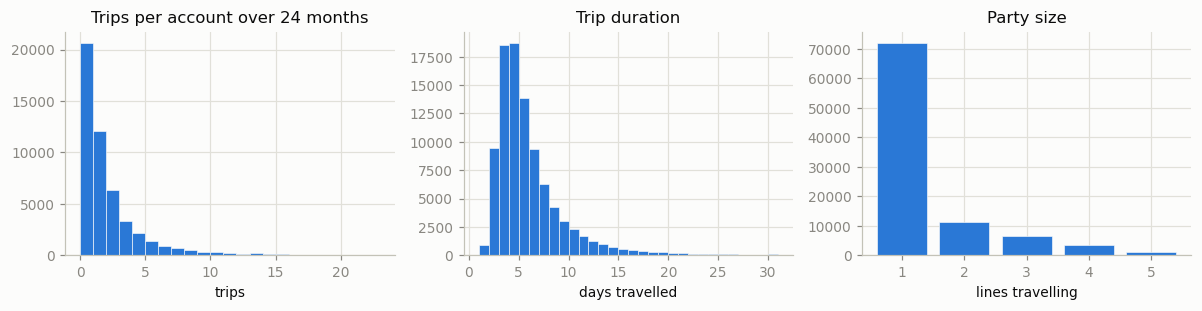

In [17]:
trips_per_account = trips.groupby("account_id").size()
all_accounts = accounts.set_index("account_id").index
trip_counts = trips_per_account.reindex(all_accounts, fill_value=0)

n_months = macro.month.nunique()
summary = pd.Series({
    "accounts": len(accounts),
    "accounts that travelled": (trip_counts > 0).sum(),
    "share that travelled": (trip_counts > 0).mean(),
    "trips total": len(trips),
    "trips per travelling account (median)": trip_counts[trip_counts > 0].median(),
    "trips per travelling account (p95)": trip_counts[trip_counts > 0].quantile(0.95),
    "months": n_months,
})
print(summary.to_string(float_format=lambda v: f"{v:,.2f}"))

fig, axes = plt.subplots(1, 3, figsize=(11, 2.9))

axes[0].hist(trip_counts, bins=range(0, int(trip_counts.quantile(0.995)) + 2),
             color=ACCENT, edgecolor=SURFACE, linewidth=0.4)
axes[0].set_title(f"Trips per account over {n_months} months")
axes[0].set_xlabel("trips")

axes[1].hist(trips["days_traveled"], bins=range(1, 32), color=ACCENT,
             edgecolor=SURFACE, linewidth=0.4)
axes[1].set_title("Trip duration")
axes[1].set_xlabel("days travelled")

party = trips["lines_traveling"].value_counts().sort_index()
axes[2].bar(party.index, party.values, color=ACCENT, edgecolor=SURFACE, linewidth=0.4)
axes[2].set_title("Party size")
axes[2].set_xlabel("lines travelling")

plt.tight_layout()
plt.show()

**What should be true here**

- A large share of accounts with zero trips — international travel is a minority behaviour.
- Trip duration right-skewed, business trips clustered short, leisure with a long tail.
- Party size dominated by 1, with a meaningful tail of household travel — that tail is where the `$5` additional-line economics live.

If duration or party size looks symmetric or flat, the generator parameters need adjusting before proceeding.

### 1.2 Business and consumer should behave differently

The entire pricing argument rests on these two groups responding differently. If they are indistinguishable in the raw data, the model has nothing to find and the segmentation will be noise.

Per trip
             trips  accounts  avg_days  avg_party  solo_share  no_purchase_rate  avg_revenue
is_business                                                                                 
consumer     40527     19667     7.247      1.567       0.641             0.127       76.410
business     53913      9645     4.183      1.286       0.858             0.070       42.869

Per account over the full window
             accounts  trips_per_account  revenue_per_account  revenue_p90
is_business                                                               
consumer        19667               2.06               157.45        352.0
business         9645               5.59               239.63        539.0


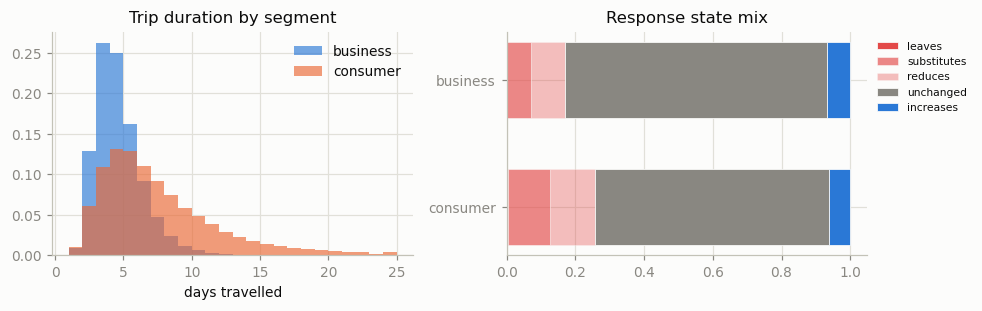

In [18]:
seg = trips.groupby("is_business").agg(
    trips=("trip_id", "size"),
    accounts=("account_id", "nunique"),
    avg_days=("days_traveled", "mean"),
    avg_party=("lines_traveling", "mean"),
    solo_share=("lines_traveling", lambda s: (s == 1).mean()),
    no_purchase_rate=("days_bought", lambda s: (s == 0).mean()),
    avg_revenue=("pass_revenue", "mean"),
).round(3)
seg.index = seg.index.map({False: "consumer", True: "business"})
print("Per trip")
print(seg.to_string())

# Per ACCOUNT is the unit a pricing decision is made on: business trips are
# smaller but far more frequent, so per-trip revenue understates the segment.
per_acct = (trips.groupby(["is_business", "account_id"])
            .agg(trips=("trip_id", "size"), revenue=("pass_revenue", "sum"))
            .groupby("is_business").agg(
                accounts=("trips", "size"),
                trips_per_account=("trips", "mean"),
                revenue_per_account=("revenue", "mean"),
                revenue_p90=("revenue", lambda s: s.quantile(0.90)),
            ).round(2))
per_acct.index = per_acct.index.map({False: "consumer", True: "business"})
print("\nPer account over the full window")
print(per_acct.to_string())

fig, axes = plt.subplots(1, 2, figsize=(9, 2.9))

# Two genuine identity series (both equally "the subject"), so categorical
# slots 1 and 2 rather than accent-vs-muted.
for flag, label, color in [(True, "business", ACCENT), (False, "consumer", ACCENT2)]:
    sub = trips[trips.is_business == flag]
    axes[0].hist(sub["days_traveled"], bins=range(1, 26), alpha=0.65,
                 label=label, color=color, density=True)
axes[0].set_title("Trip duration by segment")
axes[0].set_xlabel("days travelled")
axes[0].legend(frameon=False)

# Same diverging severity treatment as the state-mix chart above, so the two
# charts read as one consistent color language for "state" everywhere.
STATE_ORDER = ["leaves", "substitutes", "reduces", "unchanged", "increases"]
STATE_COLOR = {"leaves": RED, "substitutes": RED, "reduces": RED,
               "unchanged": MUTED, "increases": ACCENT}
STATE_ALPHA = {"leaves": 1.00, "substitutes": 0.65, "reduces": 0.35,
               "unchanged": 1.00, "increases": 1.00}

state_mix = (trips.groupby("is_business")["state"]
             .value_counts(normalize=True).unstack().fillna(0)
             .reindex(columns=STATE_ORDER))
state_mix.index = state_mix.index.map({False: "consumer", True: "business"})

left = np.zeros(len(state_mix))
for s in STATE_ORDER:
    axes[1].barh(state_mix.index, state_mix[s], left=left, height=0.6,
                 color=STATE_COLOR[s], alpha=STATE_ALPHA[s],
                 edgecolor=SURFACE, linewidth=0.5, label=s)
    left += state_mix[s].to_numpy()
axes[1].set_title("Response state mix")
axes[1].legend(frameon=False, fontsize=7, bbox_to_anchor=(1.0, 1.0))
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### 1.3 Revenue concentration

Telecom revenue is heavily concentrated. If the top decile of accounts here does not carry a disproportionate share, the population is too uniform and the "the opportunity sits in a minority of travellers" finding would be an artefact of the generator rather than a property worth reporting.

top    1% of accounts  ->   11.9% of pass revenue
top    5% of accounts  ->   34.1% of pass revenue
top   10% of accounts  ->   51.0% of pass revenue
top   20% of accounts  ->   72.3% of pass revenue
top   50% of accounts  ->   98.7% of pass revenue


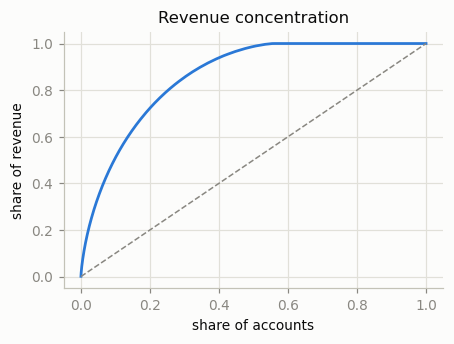

In [19]:
acct_rev = (trips.groupby("account_id")["pass_revenue"].sum()
            .reindex(all_accounts, fill_value=0).sort_values(ascending=False))

cum = acct_rev.cumsum() / acct_rev.sum()
share_of_accounts = np.arange(1, len(cum) + 1) / len(cum)

for pct in [0.01, 0.05, 0.10, 0.20, 0.50]:
    # max(..., 0) guards small populations where pct * len(cum) < 1, which
    # would otherwise index cum.iloc[-1] instead of raising.
    i = max(int(pct * len(cum)) - 1, 0)
    print(f"top {pct:>5.0%} of accounts  ->  {cum.iloc[i]:>6.1%} of pass revenue")

fig, ax = plt.subplots(figsize=(4.2, 3.2))
ax.plot(share_of_accounts, cum.values, color=ACCENT, linewidth=1.8)
ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, linestyle="--")
ax.set_xlabel("share of accounts")
ax.set_ylabel("share of revenue")
ax.set_title("Revenue concentration")
plt.tight_layout()
plt.show()

### 1.4 Macro and seasonality should be visible

Trip volume must track the macro index. This is what makes the forward simulation's correlated draws meaningful — if volume were independent of the economy here, modelling macro scenarios later would be theatre.

corr(trip volume, macro index)   = 0.892
corr(trip volume, seasonality)   = 0.492
corr(revenue, trip volume)       = 0.997


/var/folders/rj/lg_9h2v52pnckdkdmwvvw3xr0000gn/T/ipykernel_47111/3373489117.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


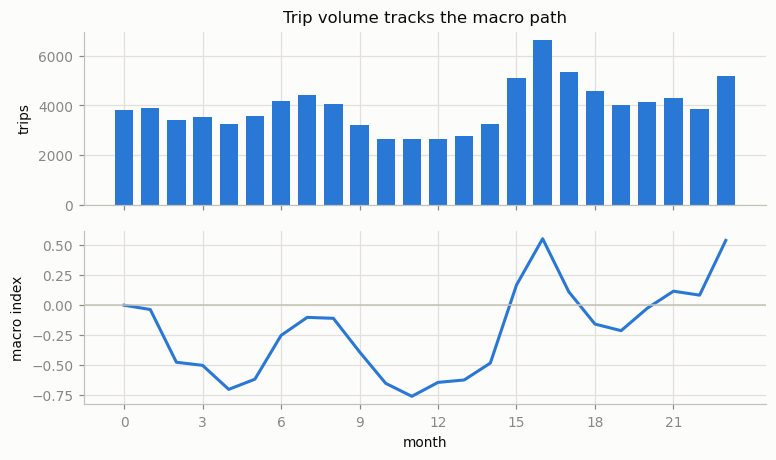

In [20]:
monthly = (trips.groupby("month")
           .agg(trips=("trip_id", "size"), revenue=("pass_revenue", "sum"))
           .reset_index().merge(macro, on="month"))

print(f"corr(trip volume, macro index)   = {monthly.trips.corr(monthly.macro_index):.3f}")
print(f"corr(trip volume, seasonality)   = {monthly.trips.corr(monthly.seasonality):.3f}")
print(f"corr(revenue, trip volume)       = {monthly.revenue.corr(monthly.trips):.3f}")

# Two small multiples sharing an x-axis rather than a dual-axis single panel:
# trips and the macro index live on different scales, and a twin y-axis would
# let the chart invent an alignment between them that isn't in the data. Same
# hue on both because it's one story (the macro path driving volume), not two
# identities.
fig, axes = plt.subplots(2, 1, figsize=(8, 4.4), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1], "hspace": 0.15})

axes[0].bar(monthly.month, monthly.trips, color=ACCENT, width=0.7)
axes[0].set_ylabel("trips")
axes[0].set_title("Trip volume tracks the macro path")

axes[1].plot(monthly.month, monthly.macro_index, color=ACCENT, linewidth=2)
axes[1].axhline(0, color=BASELINE, linewidth=1)
axes[1].set_ylabel("macro index")
axes[1].set_xlabel("month")
axes[1].set_xticks(range(0, N_MONTHS, 3))

plt.tight_layout()
plt.show()

---
## 2 · Is the label boundary readable from the data?

This is the decision that matters most. In production the five states are **not observed** — they have to be reconstructed from what is measurable:

| Observable | What it distinguishes |
|---|---|
| `days_bought == 0` | bought nothing: **substitutes** or **leaves** |
| `days_bought / days_traveled` | how much of the trip was covered |
| `lines_active / lines_traveling` | how much of the party was covered |

The hard boundary is **reduces vs unchanged**. Both bought the pass; the question is how far below full coverage counts as a deliberate reduction rather than incidental variation.

If the coverage ratio is bimodal — a spike at 1.0 and a separate spread below it — the threshold reads off the valley between them. If it is a smooth continuum, no threshold is defensible and the state has to be treated probabilistically instead.

Day coverage among trips that bought the pass
count    85486.000
mean         0.942
std          0.213
min          0.038
5%           0.500
25%          1.000
50%          1.000
75%          1.000
95%          1.167
max          3.500

exactly 1.0 : 72.3%
above 1.0   : 7.1%   (bought more days than travelled)
below 1.0   : 20.6%


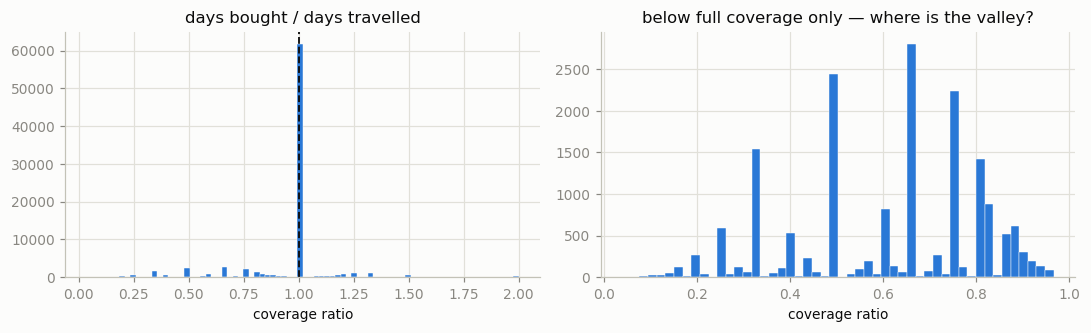

In [21]:
bought = trips[trips["days_bought"] > 0].copy()
bought["day_coverage"] = bought["days_bought"] / bought["days_traveled"]
bought["line_coverage"] = bought["lines_active"] / bought["lines_traveling"]

print("Day coverage among trips that bought the pass")
print(bought["day_coverage"].describe(percentiles=[.05, .25, .5, .75, .95]).round(3).to_string())
print(f"\nexactly 1.0 : {(bought.day_coverage == 1).mean():.1%}")
print(f"above 1.0   : {(bought.day_coverage > 1).mean():.1%}   (bought more days than travelled)")
print(f"below 1.0   : {(bought.day_coverage < 1).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.1))

axes[0].hist(bought["day_coverage"].clip(0, 2), bins=80, color=ACCENT,
             edgecolor=SURFACE, linewidth=0.3)
axes[0].axvline(1.0, color=INK, linewidth=1.2, linestyle="--")
axes[0].set_title("days bought / days travelled")
axes[0].set_xlabel("coverage ratio")

axes[1].hist(bought.loc[bought.day_coverage < 1, "day_coverage"], bins=50,
             color=ACCENT, edgecolor=SURFACE, linewidth=0.3)
axes[1].set_title("below full coverage only — where is the valley?")
axes[1].set_xlabel("coverage ratio")

plt.tight_layout()
plt.show()

### 2.1 Testing candidate thresholds against the truth

Because this is synthetic data, the true state is known. That allows something impossible with real data: **scoring the labelling rule itself.**

Each candidate rule below is applied as it would be in production — using only observables — and then compared against `state`. In production this comparison is impossible, which is exactly why establishing it here is worth the effort.

**Three rules are tested, not one.** A coverage *ratio* conflates trip lengths: one day short on a three-day trip is a 0.67 ratio and is almost certainly incidental, while one day short on a ten-day trip is 0.90 and probably also incidental. A single ratio cutoff cannot separate those, so two alternatives are tried alongside it:

| Rule | Reduces when |
|---|---|
| **ratio** | coverage falls below a cutoff |
| **absolute** | a fixed number of days went unbought, regardless of trip length |
| **combined** | materially short in days *and* below the ratio cutoff |

**Accuracy is the wrong criterion.** `unchanged` dominates the population, so a rule that labels almost nothing as `reduces` scores well while missing most of the real reductions. F1 on the minority class is reported alongside it and is what the choice should follow.

In [22]:
def apply_rule(df, day_thresh, line_thresh=0.999, rule="ratio", days_short=2):
    """Reconstruct states from observables only — no use of the true state.

    Note: 'substitutes' and 'leaves' are indistinguishable at trip level
    (both simply buy nothing). Separating them requires account-level
    evidence of departure, so they are pooled here as 'no_purchase'.
    """
    days = df["days_bought"] / df["days_traveled"]
    lines = df["lines_active"] / df["lines_traveling"].clip(lower=1)

    short = df["days_traveled"] - df["days_bought"]

    if rule == "ratio":
        is_reduce = days < day_thresh
    elif rule == "absolute":
        # A fixed number of days short, regardless of trip length
        is_reduce = short >= days_short
    elif rule == "combined":
        # Must be both materially short in days AND below the ratio cutoff.
        # One day short is incidental on any trip length; two days short on a
        # short trip is a decision.
        is_reduce = (short >= days_short) & (days < day_thresh)
    else:
        raise ValueError(rule)

    # Order matters: no_purchase is applied last so it overrides is_reduce for
    # days_bought == 0 rows (which is_reduce would otherwise also catch).
    out = pd.Series("unchanged", index=df.index, dtype=object)
    out[days > 1.0] = "increases"
    out[is_reduce | (lines < line_thresh)] = "reduces"
    out[df["days_bought"] == 0] = "no_purchase"
    return out


truth_pooled = trips["state"].replace({"substitutes": "no_purchase", "leaves": "no_purchase"})

def score(pred, label):
    tp = ((pred == "reduces") & (truth_pooled == "reduces")).sum()
    return {
        "rule": label,
        "accuracy": (pred == truth_pooled).mean(),
        "recall": tp / max((truth_pooled == "reduces").sum(), 1),
        "precision": tp / max((pred == "reduces").sum(), 1),
        "share labelled": (pred == "reduces").mean(),
    }


rows = []
rule_params = {}
for t in [0.999, 0.95, 0.90, 0.85, 0.80, 0.70, 0.60, 0.50, 0.40]:
    label = f"ratio < {t}"
    rule_params[label] = dict(day_thresh=t, rule="ratio")
    rows.append(score(apply_rule(trips, t, rule="ratio"), label))
for d in [1, 2, 3, 4]:
    label = f"short >= {d}d"
    rule_params[label] = dict(day_thresh=1.0, rule="absolute", days_short=d)
    rows.append(score(apply_rule(trips, 1.0, rule="absolute", days_short=d), label))
for d in [2, 3]:
    for t in [0.95, 0.85, 0.75]:
        label = f"short >= {d}d and ratio < {t}"
        rule_params[label] = dict(day_thresh=t, rule="combined", days_short=d)
        rows.append(score(apply_rule(trips, t, rule="combined", days_short=d), label))

res = pd.DataFrame(rows).set_index("rule").round(4)
res["f1"] = (2 * res.precision * res.recall / (res.precision + res.recall)).round(4)
print(res.to_string())

true_share = (truth_pooled == "reduces").mean()
print(f"\nTrue share reducing: {true_share:.4f}")
print(f"Best F1:      {res.f1.idxmax()}  (F1 {res.f1.max():.3f})")
print(f"Best accuracy: {res.accuracy.idxmax()}  ({res.accuracy.max():.1%})")

# Accuracy is dominated by 'unchanged' and rewards under-labelling. F1 on the
# minority class is the honest criterion here.
# Chosen on F1 and on the asymmetry argument above: of the top F1 rules, this
# one has the higher recall, and missing a real reduction is the more costly
# error than over-labelling one — so it's not simply the argmax of F1.
# Derived from `rule_params` (not hand-typed) so BEST_RULE always matches an
# actual row above, and checked against the F1 ranking so a change in the
# underlying data that drops it out of contention doesn't pass silently.
BEST_LABEL = "ratio < 0.7"
assert BEST_LABEL in res.index, f"{BEST_LABEL!r} not among the candidate rules tested above"
BEST_RULE = rule_params[BEST_LABEL]
best_rank = int(res.f1.rank(ascending=False)[BEST_LABEL])
print(f"\nChosen rule: {BEST_LABEL}  ->  {BEST_RULE}")
print(f"F1 = {res.loc[BEST_LABEL, 'f1']:.3f}, precision = {res.loc[BEST_LABEL, 'precision']:.3f}, "
      f"recall = {res.loc[BEST_LABEL, 'recall']:.3f}  (rank {best_rank} of {len(res)} by F1)")
assert best_rank <= 3, (
    f"{BEST_LABEL!r} dropped to rank {best_rank} by F1 — the asymmetric-cost "
    "argument for choosing it over the top F1 rule no longer holds; re-pick BEST_RULE."
)

                              accuracy  recall  precision  share labelled      f1
rule                                                                             
ratio < 0.999                   0.9156  0.9523     0.5762          0.1864  0.7180
ratio < 0.95                    0.9165  0.9522     0.5789          0.1856  0.7200
ratio < 0.9                     0.9223  0.9491     0.5981          0.1790  0.7338
ratio < 0.85                    0.9311  0.9354     0.6314          0.1671  0.7539
ratio < 0.8                     0.9444  0.8870     0.7002          0.1429  0.7826
ratio < 0.7                     0.9507  0.7898     0.7772          0.1147  0.7834
ratio < 0.6                     0.9487  0.6064     0.9086          0.0753  0.7274
ratio < 0.5                     0.9277  0.3891     0.9277          0.0473  0.5483
ratio < 0.4                     0.9194  0.3157     0.9124          0.0390  0.4691
short >= 1d                     0.9156  0.9523     0.5762          0.1864  0.7180
short >= 2d     

In [23]:
# Where the chosen rule gets it wrong — the errors matter more than the accuracy
pred = apply_rule(trips, **BEST_RULE)
confusion = pd.crosstab(truth_pooled, pred, normalize="index").round(3)
confusion.index.name = "true state"
confusion.columns.name = "labelled as"
print(confusion.to_string())

labelled as  increases  no_purchase  reduces  unchanged
true state                                             
increases          1.0          0.0    0.000      0.000
no_purchase        0.0          1.0    0.000      0.000
reduces            0.0          0.0    0.790      0.210
unchanged          0.0          0.0    0.035      0.965


**Reading the confusion table.** Two failure modes matter and they are not symmetric.

- **Reduces labelled unchanged** understates price damage. The model learns that customers tolerate increases better than they do, and the revenue case is optimistic.
- **Unchanged labelled reduces** overstates it, and the recommendation becomes needlessly timid.

Given the decision at stake — a price increase that leadership is already nervous about — the second error is the safer one to make. Worth choosing the threshold accordingly rather than purely maximising accuracy.

**On `no_purchase`.** Substitutes and leaves cannot be separated at trip level: both look like an absence of purchase. They are pooled here deliberately. Splitting them requires account-level evidence of departure, which belongs in the modelling notebook, not the labelling rule.

---
## 3 · Is there enough price variation — per segment?

A price response can only be estimated where the price actually moved. Checked overall this almost always looks fine; checked per segment it frequently does not, and a segment whose sensitivity cannot be estimated will silently inherit the population average.

That failure is invisible in model metrics and shows up only when a pricing decision is made for a group the model never had evidence about.

In [24]:
print("Overall price exposure")
print(trips["price_multiplier"].value_counts(normalize=True).sort_index().round(4).to_string())
print(f"\nShare of trips off the standard rate: {(trips.price_multiplier != 1.0).mean():.1%}")

trips["party_band"] = pd.cut(trips["lines_traveling"], [0, 1, 2, 10],
                             labels=["solo", "pair", "3+"])
trips["segment"] = (pd.Series(np.where(trips.is_business, "business", "consumer"),
                               index=trips.index)
                      .str.cat(trips.party_band.astype(str), sep=" / "))

variation = trips.pivot_table(index="segment", columns="price_multiplier",
                              values="trip_id", aggfunc="count").fillna(0).astype(int)
variation["total"] = variation.sum(axis=1)
variation["off-standard %"] = (1 - variation[1.0] / variation["total"]).round(3)
print("\nTrips by segment and price multiplier")
print(variation.to_string())

Overall price exposure
price_multiplier
0.90    0.0651
0.95    0.0819
1.00    0.6711
1.10    0.1087
1.20    0.0732

Share of trips off the standard rate: 32.9%

Trips by segment and price multiplier
price_multiplier   0.9  0.95    1.0   1.1   1.2  total  off-standard %
segment                                                               
business / 3+      299   436   3262   525   406   4928           0.338
business / pair    159   229   1822   321   213   2744           0.336
business / solo   2994  3730  31087  5036  3394  46241           0.328
consumer / 3+      397   473   3946   625   437   5878           0.329
consumer / pair    584   715   5870   922   594   8685           0.324
consumer / solo   1712  2153  17394  2833  1872  25964           0.330


In [25]:
# Minimum cell size for a segment's response to be estimable at all
MIN_CELL = 300

cells = (trips.groupby(["segment", "price_multiplier"]).size()
         .rename("n").reset_index())
thin = cells[cells.n < MIN_CELL]

if thin.empty:
    print(f"All segment x price cells have at least {MIN_CELL} trips.")
else:
    print(f"Cells below {MIN_CELL} trips — sensitivity here will not be estimable:\n")
    print(thin.sort_values("n").to_string(index=False))

# Does the naive elasticity signal actually appear per segment?
print("\nNo-purchase rate by segment and price — the raw signal the model must find")
signal = trips.pivot_table(index="segment", columns="price_multiplier",
                           values="days_bought", aggfunc=lambda s: (s == 0).mean()).round(3)
print(signal.to_string())

Cells below 300 trips — sensitivity here will not be estimable:

        segment  price_multiplier   n
business / pair              0.90 159
business / pair              1.20 213
business / pair              0.95 229
  business / 3+              0.90 299

No-purchase rate by segment and price — the raw signal the model must find
price_multiplier   0.90   0.95   1.00   1.10   1.20
segment                                            
business / 3+     0.070  0.060  0.067  0.078  0.116
business / pair   0.082  0.066  0.074  0.090  0.103
business / solo   0.057  0.064  0.067  0.080  0.098
consumer / 3+     0.101  0.104  0.117  0.168  0.224
consumer / pair   0.104  0.130  0.122  0.172  0.200
consumer / solo   0.085  0.115  0.117  0.161  0.201


### 3.1 The confounding is real — and that is intentional

The price multiplier was assigned by region and period, not at random. Heavy travellers, particular destinations and the higher-price windows overlap, so a naive comparison of outcomes across price levels attributes those differences to price.

The check below shows how much. If the raw difference and the within-segment difference disagree, the modelling notebook must control for it — and this is the evidence for why.

In [26]:
high = trips[trips.price_multiplier >= 1.10]
base = trips[trips.price_multiplier == 1.0]

print("Naive comparison, high price vs standard")
print(f"  business share    {high.is_business.mean():.3f}  vs  {base.is_business.mean():.3f}")
print(f"  europe/apac share {high.region.isin(['europe','apac']).mean():.3f}  vs  "
      f"{base.region.isin(['europe','apac']).mean():.3f}")
print(f"  avg days          {high.days_traveled.mean():.2f}  vs  {base.days_traveled.mean():.2f}")

raw = high.days_bought.eq(0).mean() - base.days_bought.eq(0).mean()
print(f"\nRaw difference in no-purchase rate: {raw:+.4f}")

within = []
for (seg_, reg), g in trips.groupby(["segment", "region"]):
    h = g[g.price_multiplier >= 1.10]
    b = g[g.price_multiplier == 1.0]
    if len(h) >= 100 and len(b) >= 100:
        within.append((h.days_bought.eq(0).mean() - b.days_bought.eq(0).mean(), len(h) + len(b)))

if within:
    diffs, weights = zip(*within)
    print(f"Within segment x region:            {np.average(diffs, weights=weights):+.4f}")
    print(f"Confounding accounts for:           {raw - np.average(diffs, weights=weights):+.4f}")

Naive comparison, high price vs standard
  business share    0.576  vs  0.571
  europe/apac share 0.884  vs  0.428
  avg days          5.49  vs  5.50

Raw difference in no-purchase rate: +0.0383
Within segment x region:            +0.0225
Confounding accounts for:           +0.0158


---
## 4 · Recovering the truth

A final check available only with synthetic data: does observable behaviour actually carry the latent sensitivity signal?

Accounts are bucketed by their true sensitivity decile and their observed behaviour compared. If the most and least sensitive deciles behave identically at higher prices, no model will separate them and the generator needs stronger signal. If they separate cleanly, the signal is present and any later failure to find it is a modelling problem.

**Read value per account, not per trip.** Sensitivity is correlated with travel frequency, and the least sensitive accounts are business accounts whose trips are short and solo. Per-trip revenue therefore runs *inverse* to insensitivity, which inverts the finding. Any claim that the upside sits with high-value, price-insensitive customers has to be made per account.

Behaviour at elevated prices, by TRUE sensitivity decile
(decile 0 = most sensitive)

                    trips  no_purchase  avg_coverage  avg_revenue
sensitivity_decile                                               
0                     807        0.202         4.836       73.435
1                     825        0.189         5.161       75.288
2                     842        0.196         5.068       72.511
3                     898        0.179         5.158       75.302
4                    1004        0.176         4.904       71.725
5                    1154        0.162         5.175       75.762
6                    1324        0.142         4.730       67.228
7                    2027        0.114         4.151       58.316
8                    3186        0.102         3.748       50.431
9                    5111        0.085         3.535       46.224

Value per account by sensitivity decile — the unit a price decision uses
                    accounts  trips_per_account 

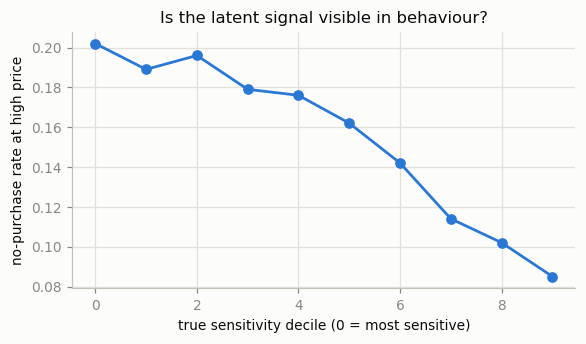


Spread, most vs least sensitive decile: +0.117
Signal is present and learnable.


In [27]:
gt = trips.merge(ground_truth[["account_id", "sensitivity_decile"]], on="account_id")
high_price = gt[gt.price_multiplier >= 1.10]

by_decile = high_price.groupby("sensitivity_decile").agg(
    trips=("trip_id", "size"),
    no_purchase=("days_bought", lambda s: (s == 0).mean()),
    avg_coverage=("days_bought", "mean"),
    avg_revenue=("pass_revenue", "mean"),
).round(3)
print("Behaviour at elevated prices, by TRUE sensitivity decile")
print("(decile 0 = most sensitive)\n")
print(by_decile.to_string())

# Per-trip revenue is confounded: the least sensitive accounts are business, and
# business trips are short and solo. Value has to be read per ACCOUNT.
# Uses `gt` (the full window, not just `high_price`) — deliberately: the value
# a price decision cares about is what an account is worth overall, not just
# what it spends during the elevated-price trips being diagnosed above.
acct_decile = (gt.groupby(["sensitivity_decile", "account_id"])
               .agg(trips=("trip_id", "size"), revenue=("pass_revenue", "sum"))
               .groupby("sensitivity_decile").agg(
                   accounts=("trips", "size"),
                   trips_per_account=("trips", "mean"),
                   revenue_per_account=("revenue", "mean"),
               ).round(2))
print("\nValue per account by sensitivity decile — the unit a price decision uses")
print(acct_decile.to_string())

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.plot(by_decile.index, by_decile.no_purchase, marker="o", color=ACCENT, linewidth=1.8)
ax.set_xlabel("true sensitivity decile (0 = most sensitive)")
ax.set_ylabel("no-purchase rate at high price")
ax.set_title("Is the latent signal visible in behaviour?")
plt.tight_layout()
plt.show()

spread = by_decile.no_purchase.iloc[0] - by_decile.no_purchase.iloc[-1]
print(f"\nSpread, most vs least sensitive decile: {spread:+.3f}")
print("Signal is present and learnable." if abs(spread) > 0.05
      else "Signal too weak — increase sensitivity dispersion in notebook 01.")

---
## What this notebook deliberately does not do

**It does not assign labels for the modelling notebooks to consume.** `state` above is the *true* generating state, used only to validate the reconstruction rule in Part 2. `01_state_model.ipynb` reconstructs labels itself from observable quantities — `days_bought` against `days_traveled`, `lines_active` against `lines_traveling` — exactly as it would from real data, using the rule Part 2 selected and scored.

**It does not simulate forward.** This is the historical panel the models are fit on. The 12-month forward Monte Carlo is a separate notebook (`03_simulation.ipynb`): it re-runs the fitted models across the −10% to +20% price range under expansion, base and contraction paths, drawing the macro shock **once per iteration** and applying it to every account, so revenue outcomes stay correlated.

**It does not tune anything to a target.** No parameter here was chosen to make the answer come out at a particular number. The generator is a plausible world; whatever the analysis finds in it is what it finds.

## Decisions Part 2 produces

Record these before moving on; the modelling notebooks depend on all four.

| Decision | Set by |
|---|---|
| **Day coverage threshold** for reduces vs unchanged | §2.1, adjusted toward over-labelling reduces rather than under |
| **`substitutes` and `leaves` are pooled** at trip level | §2.1 — inseparable without account-level departure evidence |
| **Segments with thin price variation** | §3, flagged as not estimable rather than silently averaged |
| **Confounding must be controlled** | §3.1 — raw and within-segment differences disagree |

### Fix in Part 1 above if

- Party size or duration looks symmetric rather than skewed.
- Revenue concentration is close to uniform.
- Trip volume does not track the macro index.
- The sensitivity-decile spread in §4 is under ~5 points.

### Next

`01_state_model.ipynb` — multiclass model on the reconstructed labels, split by time rather than at random, with class weighting for the rare states and calibration curves before any of it feeds a simulation.